# Full example

## Let's bring it all together

Now, let us try to bring it all together to fully see what we can do with all of this together.
For this let us:

1. Get a list of Wikipedia articles about politicians and for each article the number of unique editors, the gender classification and the 'quality rating'
2. For each contributor to those articles: Get the number of politician pages they contributed to that are male/female and calculate a "specialisation" score (ratio of male/female articles edited)
3. For each politician article: sum over all specialisation scores for the editors, and plot against # of editors overall and ['quality rating'](https://en.wikipedia.org/wiki/Wikipedia:Content_assessment)

## Getting the articles

As we have seen before, there are around 1,000 Wikidata entries about Kenyan politicians.
To keep things manageable for our test. Let's start with a smaller number, and let's also again try to get a more balanced sample of pages with respect to gender.

### Some initial setup

Let's load our libraries and prepare some functions we'll be using to get this data:

In [5]:
import pywikibot # loading the pywikibot library
from pywikibot import pagegenerators as pg # import the page generator so we can iterate over all returned Wikidata items

import pandas as pd # loading pandas for data manipulation

WIKIPEDIA_SITE = pywikibot.Site("en", 'wikipedia') # creating an English WP site object to get page details

WIKIDATA_SITE = pywikibot.Site("wikidata", 'wikidata')


def get_gender(wikidata_item):
    '''
    Look at the property for gendre and return the
    english language gender label if present. If not,
    return "unknown" - useful when our queries do not
    presume the response
    '''
    if "P21" in wikidata_item.claims.keys():
        return wikidata_item.claims['P21'][0].target.labels['en']
    else:
        return "unknown"


def get_content_assessment(p):
    '''
    Takes a regular page object to first get the 
    associated talk page (assessments are on those)
    and then return the assessment found.
    '''
    assessment = ["FA", "FL", "FM", "A", "GA", "B", "C", "Start", "Stub"]
    tpage = p.toggleTalkPage()
    for c in tpage.categories(): # iterate over all categories
        for a in assessment: # iterate over possible asssements
            if c.title().startswith("Category:{}-Class".format(a)):
                return a # found assessment category and return  
    return None # if none found, return None

def run_query(QUERY):
    '''
    Run's the handed query and returns a dictionary that contains
    the following information, for politicians that have an article
    in the English language wikipedia
    1. Item ID in wikidata
    2. name of Wikipedia page
    3. gender of politician
    4. number of unique editors
    5. quality rating
    '''
    generator = pg.WikidataSPARQLPageGenerator(QUERY, site=WIKIDATA_SITE)

    politician_data = {}

    for item in generator:
        qid = item.getID() # get unique ID
        # check that has english language article:
        if 'enwiki' in item.sitelinks.keys():
            page_title = item.sitelinks['enwiki'].canonical_title()
            page = pywikibot.Page(WIKIPEDIA_SITE, page_title)

            politician_data[qid] = {} # initialize dictionary 
            politician_data[qid]['gender'] = get_gender(item) # add gender
            politician_data[qid]['name'] = page_title # add english article name
            politician_data[qid]['content_assessment'] = get_content_assessment(page)
            contributors = list(page.contributors())
            politician_data[qid]['contributor_count'] = len(contributors)
            politician_data[qid]['contributor_list'] = contributors
    return politician_data

### Writing our queries and executing them

Let's now get 50 articles each for male and female politicians to get us started:

In [9]:
male_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581097; # male
}
LIMIT 50
"""

female_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581072; # female
}
LIMIT 50
"""

page_data_male = run_query(male_query)
page_data_female = run_query(female_query)

Now that we got our two dictionaries, we can merge them into a data frame as we've done before:

In [11]:
all_page_data = page_data_male | page_data_female
df_all_page_data = pd.DataFrame(all_page_data).T
df_all_page_data

,gender,name,content_assessment,contributor_count,contributor_list
Q1372633,male,Gitobu Imanyara,C,37,"[Zackmann08, Ser Amantio di Nicolao, Xrimoncia..."
Q47493967,male,Suleiman Dori,Stub,13,"[Zackmann08, SdkbBot, Citation bot, Ser Amanti..."
Q457713,male,Newton Kulundu,Start,50,"[Otubula, PrimeBOT, Zackmann08, Thoppy234, Per..."
Q57291,male,Mwai Kibaki,B,972,"[HamiltonianXLVII, Shogeneral, AnomieBOT, ~202..."
Q593552,male,Michael Kijana Wamalwa,C,94,"[JemimaV, Zackmann08, SuperCode111, ~2025-3133..."
...,...,...,...,...,...
Q47483883,female,Elsie Busihile Muhanda,Stub,2,"[Jevansen, Ojewuyib]"
Q47490074,female,Beatrice Nkatha,Stub,7,"[Arkistointi, DaniloDaysOfOurLives, Jevansen, ..."
Q47490065,female,Jerusha Mongina Momanyi,Start,9,"[A.Deira.born, LionmerterTHE, Ser Amantio di N..."
Q47490071,female,Christine Ombaka,Stub,7,"[Zackmann08, Adini Anna, Masohpotato, Jevansen..."


Now we got the data frame with the information we want for each article so far, along with the list of contributors.

## Classifying contributros

This allows us to now aggregate the information about the contributors and how many male/female biographies they have contributed to. For this, we iterate over all the rows we have and count how many female or male articles they have contributed to:

In [34]:
from collections import defaultdict

# the default value for our dictionary is a sub-dictionary
# this makes it easier to create a dictionary of dictionaries
# in this form:
# {'editor_name': {
#    'male': 10, 
#    'female': 15},
#  'editor_2': {
#    'male': 1, 
#    'female': 4},
#}

editors = defaultdict(dict)

for index, row in df_all_page_data.iterrows():
    for contributor in row['contributor_list']:
        if row['gender'] in editors[contributor].keys():
            editors[contributor][row['gender']] += 1
        else:
            editors[contributor][row['gender']] = 1

# let's convert it into a DF as well
df_editors = pd.DataFrame(editors).T
df_editors

,male,female
Zackmann08,34.0,18.0
Ser Amantio di Nicolao,35.0,22.0
Xrimonciam,1.0,2.0
Bearcat,3.0,11.0
Rathfelder,6.0,2.0
...,...,...
Elosymakena1,NaN,1.0
Njoro Em,NaN,1.0
69.248.159.60,NaN,1.0
41.206.53.226,NaN,1.0


As we can see, some of those values wil be `NaN` (*not a number*) as the editors haven't contributed to one of the two categories. In reality, those missing bits are `0`, so let's replace those:

In [36]:
df_editors = df_editors.fillna(0)

Now we can count the total number of pages the users edited (that is, pages in our sample, not the total pages they ever edited!) and then get the fraction of edits that went to male edits:

In [42]:
df_editors['total_pages'] = df_editors['male'] + df_editors['female']
df_editors['percent_male'] = df_editors['male'] /  df_editors['total_pages']  

<Axes: ylabel='Frequency'>

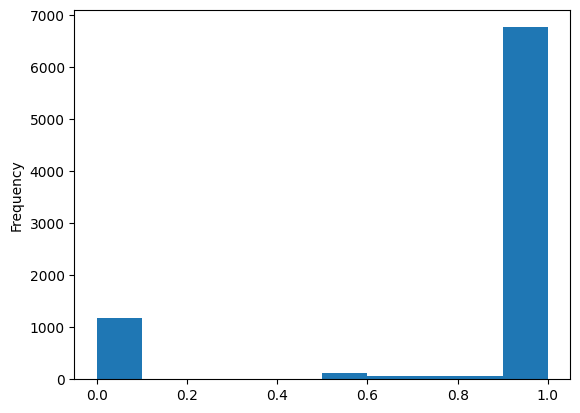

In [53]:
df_editors['percent_male'].plot(kind='hist')

That looks very strongly bi-modal. But this could be an artifact, if we remember participation inequality in Wikipedia: The vast majority of users here will have likely only done a single edit, which by definition would end up in either in the 0% or 100% group. Let's plot that number of edited pages to explore this:

<Axes: ylabel='Frequency'>

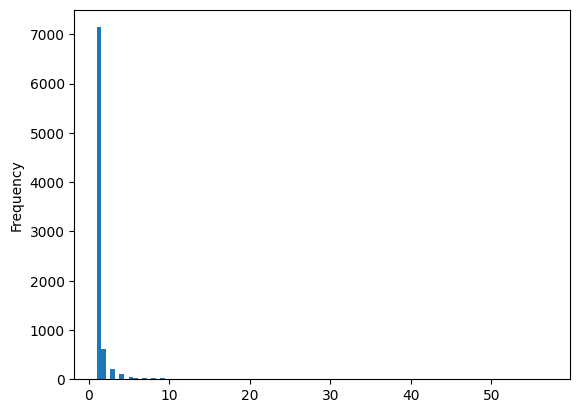

In [58]:
df_editors['total_pages'].plot(kind='hist',bins=100)

As expected, we see that over 7000 of our around 8000 editors only touched a single page, heavily biasing our results. Let's require people to have at least edited 2 pages to avoid this:

<Axes: ylabel='Frequency'>

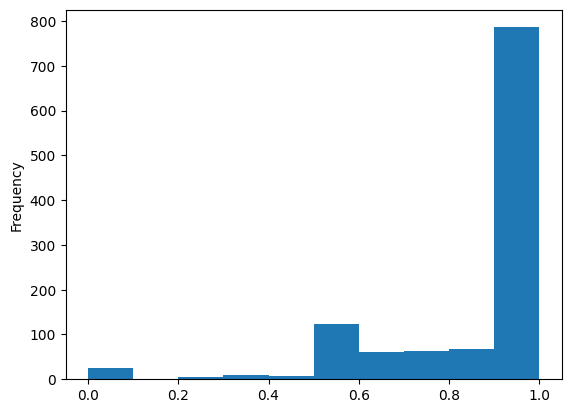

In [61]:
df_editors[df_editors['total_pages']>=2]['percent_male'].plot(kind='hist')

In [64]:
df_editors.loc[['Zackmann08']]

,male,female,total_pages,percent_male
Zackmann08,34.0,18.0,52.0,0.653846


## Classify articles by mean specialisation score

While we still see a strong male-bias, this removes the large outliers that were purely a statistical artifact. We can now use those editor classifications to calculate the 'specialisation' score:

In [110]:
def calculate_specialisation_score(row,df_editors):
    '''
    give average "specialisation" score
    for all contributors who touched article
    and edited 2+ articles in set
    '''
    score = 0
    contribs = 0
    for contributor in row['contributor_list']:
        if contributor in df_editors.index:
            score += float(
                df_editors.loc[[contributor]]['percent_male'].iloc[0]
            )
            contribs += 1
    if contribs:
        return score / contribs
    else:
        return None

filtered_editors = df_editors[df_editors['total_pages']>=2]

df_all_page_data['specialisation_score'] = df_all_page_data.apply(
    calculate_specialisation_score,
    axis=1,
    args=[filtered_editors])

df_all_page_data.head()

,gender,name,content_assessment,contributor_count,contributor_list,specialisation_score
Q1372633,male,Gitobu Imanyara,C,37,"[Zackmann08, Ser Amantio di Nicolao, Xrimoncia...",0.813884
Q47493967,male,Suleiman Dori,Stub,13,"[Zackmann08, SdkbBot, Citation bot, Ser Amanti...",0.786766
Q457713,male,Newton Kulundu,Start,50,"[Otubula, PrimeBOT, Zackmann08, Thoppy234, Per...",0.832903
Q57291,male,Mwai Kibaki,B,972,"[HamiltonianXLVII, Shogeneral, AnomieBOT, ~202...",0.908355
Q593552,male,Michael Kijana Wamalwa,C,94,"[JemimaV, Zackmann08, SuperCode111, ~2025-3133...",0.904650


Now that we got the data frame above, we can actually plot our data, by comparing the specialisation score depending on the contributor count and the content assessment:

<Axes: xlabel='contributor_count', ylabel='specialisation_score'>

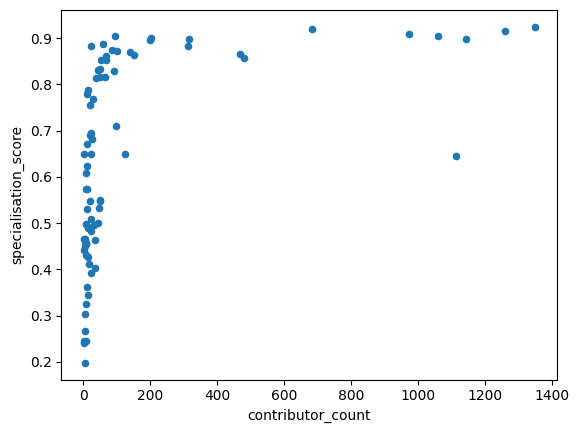

In [111]:
df_all_page_data.plot(x='contributor_count',y='specialisation_score',kind='scatter')

We see how the articles specialisation score reaches the 'average' as the number of contributors grows, approximating the distribution of gender of politicians represented in Wikidata.

When we look at the 'content assessment in relation to the average specialisation, we find that the stub articles overall have a lower score: 

specialisation_score    Axes(0.125,0.11;0.775x0.77)
dtype: object

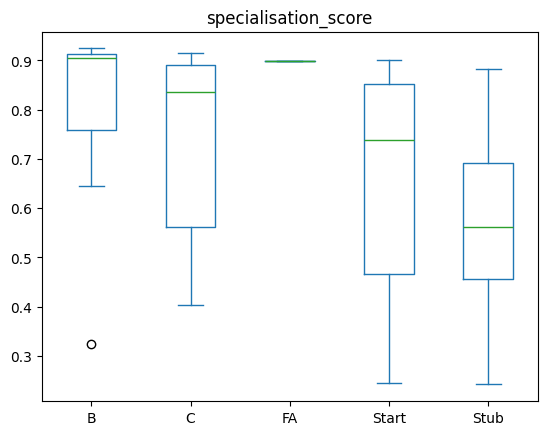

In [114]:
df_all_page_data.plot(by=['content_assessment'],column='specialisation_score',kind='box')


Given that stub articles are smaller (and likely newer/with fewer editors), this might be an artifact of just approximating the number of contributors. Let's see how the number of editors varies between those categories:

contributor_count    Axes(0.125,0.11;0.775x0.77)
dtype: object

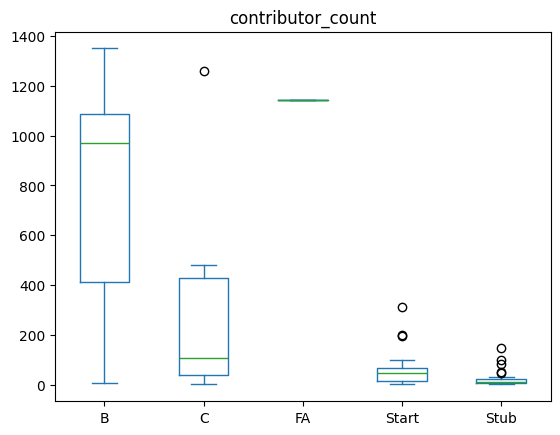

In [116]:
df_all_page_data.plot(by=['content_assessment'],column='contributor_count',kind='box')


We see that indeed, the 'higher rated' articles tend to have a lot more editors than those who are marked as 'start' or 'stubs'. One thing we didn't take into account so far are bot accounts. What happens if we'd redo this whole work without bot accounts?

Let's remove them from our scoring too, similar how we removed the accounts with only a single edit.

**Note:** For now we are using a very lazy approach of just checking if `bot` or `Bot` appears as a substring in the name of an account – this is **not reliable** - there will accidental mismatches (c.f. the [Scunthorpe problem](https://en.wikipedia.org/wiki/Scunthorpe_problem)) and some bot accounts might not carry *bot* in the name. For a more rigorous check, you should check the Wikipedia user groups, as outlined in the introduction!

Despite those caveats, let's try this as a first step, to avoid querying the API some thousands of times:

In [142]:
df_editors['is_bot'] = df_editors.apply(lambda x: ("bot" in x.name) or ("Bot" in x.name), axis=1)
df_editors.head(20)

,male,female,total_pages,percent_male,is_bot
Zackmann08,34.0,18.0,52.0,0.653846,False
Ser Amantio di Nicolao,35.0,22.0,57.0,0.614035,False
Xrimonciam,1.0,2.0,3.0,0.333333,False
Bearcat,3.0,11.0,14.0,0.214286,False
Rathfelder,6.0,2.0,8.0,0.750000,False
SdkbBot,22.0,7.0,29.0,0.758621,True
Monkbot,22.0,4.0,26.0,0.846154,True
InternetArchiveBot,24.0,10.0,34.0,0.705882,True
GreenC bot,24.0,4.0,28.0,0.857143,True
Tigercompanion25,5.0,0.0,5.0,1.000000,False


Now we can filter for accounts with edits to 2+ pages and not carrying *bot in the name*, redo our score calculation and plot the same curve:

<Axes: xlabel='contributor_count', ylabel='specialisation_score_no_bots'>

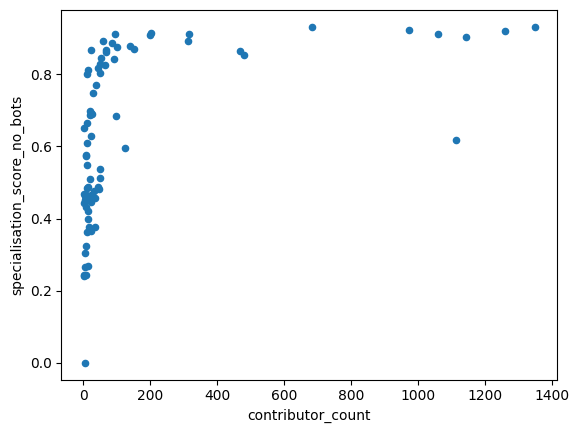

In [152]:
filtered_editors = df_editors.loc[(df_editors['total_pages']>=2) & (df_editors['is_bot'] != True)]


df_all_page_data['specialisation_score_no_bots'] = df_all_page_data.apply(
    calculate_specialisation_score,
    axis=1,
    args=[filtered_editors])

df_all_page_data.plot(x='contributor_count',y='specialisation_score_no_bots',kind='scatter')

This looks very similar, let's make a scatter plot between the two scores:

<Axes: xlabel='specialisation_score', ylabel='specialisation_score_no_bots'>

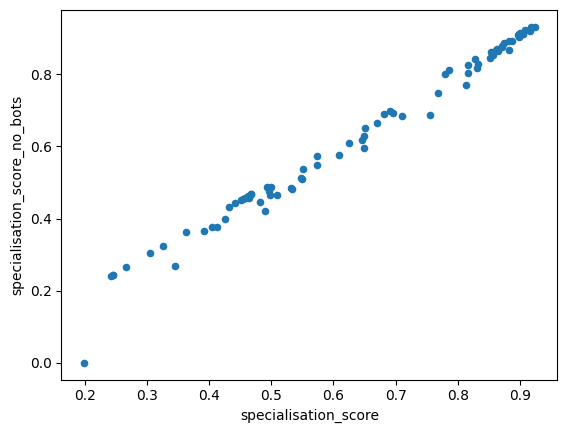

In [153]:
df_all_page_data.plot(x='specialisation_score',y='specialisation_score_no_bots',kind='scatter')

For some entries that seems to drop the calculated scores a bit, but looks quite similar overall, and we can see the same for the content assessment:

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

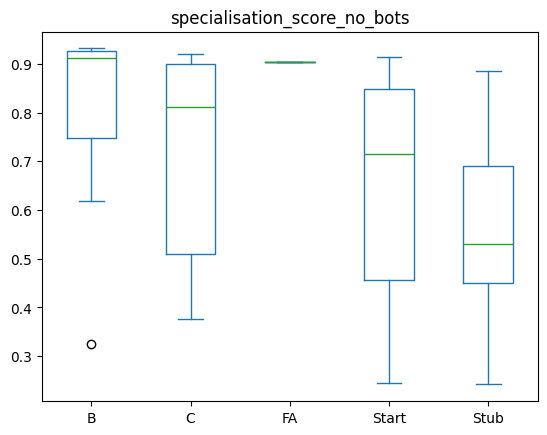

In [154]:
df_all_page_data.plot(by=['content_assessment'],column='specialisation_score_no_bots',kind='box')